# Домашнее задание 1. Базовые компоненты нейронных сетей



Домашнее задание состоит из 9 задач, разделенных на три уровня сложности:

| Уровень | Задачи | Баллы               |
|---------|--------|---------------------|
| **Простые** | 1—4    | 3 ( 0.75 за задачу) |
| **Средние** | 5—7    | 3 (1 за задачу)     |
| **Сложные** | 8—9    | 4 (2 за задачу)     |

**Итого:** 10 баллов

## Настройка окружения

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.datasets import make_moons, make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, classification_report
import seaborn as sns
import random
import warnings
warnings.filterwarnings('ignore')

# Фиксируем seed для воспроизводимости
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)


---

# ПРОСТЫЕ ЗАДАЧИ (1—4)

Эти задачи на понимание базовых концепций: линейные функции, активации, градиентный спуск.

## Задача 1. Линейная функция и нейрон

### Постановка задачи

Обучите простейший линейный классификатор (один нейрон без скрытых слоев) на двумерных данных.

**Теоретический минимум:**
- Линейный нейрон: $y = w_1 x_1 + w_2 x_2 + b$
- Сигмоида для бинарной классификации: $\sigma(z) = \frac{1}{1 + e^{-z}}$
- Бинарная кросс-энтропия: $L = -\frac{1}{N} \sum [y \log(\hat{y}) + (1-y) \log(1-\hat{y})]$

### Задача
1. Сгенерируйте две линейно разделимые двумерные выборки (используйте `make_moons` или нарисуйте сами).
2. Обучите линейный классификатор (используйте PyTorch или NumPy).
3. Визуализируйте:
   - Исходные точки двух классов.
   - Разделяющую линию (границу решения).
4. Выведите финальную точность (Accuracy) на тестовой выборке.

**Подсказка:** `torch.nn.Linear`, `torch.nn.BCEWithLogitsLoss`

Test accuracy: 1.000


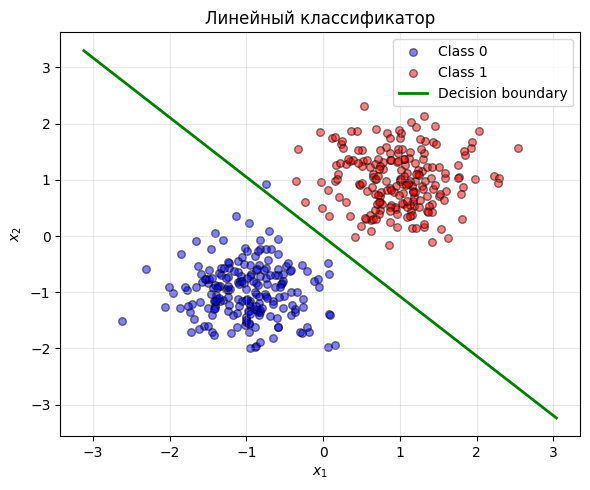

In [2]:
# Генерация линейно разделимых данных
n = 400
cov = np.array([[0.25, 0.0], [0.0, 0.25]])
x0 = np.random.multivariate_normal(mean=[-1.0, -1.0], cov=cov, size=n // 2)
x1 = np.random.multivariate_normal(mean=[1.0, 1.0], cov=cov, size=n // 2)

# Объединяем данные: X shape (400, 2), y shape (400,)
X_np = np.vstack([x0, x1])                          # (400, 2)
y_np = np.concatenate([np.zeros(n // 2), np.ones(n // 2)])  # (400,)

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X_np, y_np, test_size=0.25, random_state=SEED, stratify=y_np
)

# Конвертируем в тензоры PyTorch
# X: float32, shape (N, 2)
# y: float32, shape (N, 1) - BСЕWithLogitsLoss ожидает одинаковые размерности
X_train_t = torch.tensor(X_train, dtype=torch.float32)   # (300, 2)
X_test_t = torch.tensor(X_test, dtype=torch.float32)      # (100, 2)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)  # (300, 1)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)    # (100, 1)
# .view(-1, 1) - преобразуем вектор (N,) в столбец (N, 1),
# чтобы размерности совпадали с выходом nn.Linear(2, 1)

# Определяем модель: один линейный нейрон 
model_lin = nn.Linear(2, 1)  # y = w1*x1 + w2*x2 + b, выход shape (N, 1)

# Loss: BCEWithLogitsLoss - принимает ЛОГИТЫ (до sigmoid)
criterion = nn.BCEWithLogitsLoss()

# Оптимизатор: SGD с learning rate 0.5
optimizer = torch.optim.SGD(model_lin.parameters(), lr=0.5)

# Обучение
num_epochs = 200
for epoch in range(num_epochs):
    model_lin.train()

    # Forward pass: вычисляем логиты
    logits = model_lin(X_train_t)          # (300, 1) - сырые выходы (логиты)
    loss = criterion(logits, y_train_t)    # BCEWithLogitsLoss сама применит sigmoid

    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# Оценка на тестовой выборке
model_lin.eval()
with torch.no_grad():
    logits_test = model_lin(X_test_t)                    # (100, 1) - логиты
    probs_test = torch.sigmoid(logits_test)              # (100, 1) - вероятности
    preds_test = (probs_test >= 0.5).float()             # (100, 1) - бинарные предсказания

acc = accuracy_score(y_test_t.numpy(), preds_test.numpy())
print(f"Test accuracy: {acc:.3f}")

# Визуализация: точки + разделяющая линия
plt.figure(figsize=(6, 5))

# Рисуем точки двух классов
plt.scatter(X_np[y_np == 0, 0], X_np[y_np == 0, 1],
            c='blue', label='Class 0', alpha=0.5, edgecolors='k', s=30)
plt.scatter(X_np[y_np == 1, 0], X_np[y_np == 1, 1],
            c='red', label='Class 1', alpha=0.5, edgecolors='k', s=30)

# Разделяющая линия: w1*x1 + w2*x2 + b = 0  =>  x2 = -(w1*x1 + b) / w2
w = model_lin.weight.data.numpy().flatten()  # (2,)
b = model_lin.bias.data.numpy().item()       # скаляр

x1_line = np.linspace(X_np[:, 0].min() - 0.5, X_np[:, 0].max() + 0.5, 200)
# Проверяем, что w[1] != 0, чтобы избежать деления на ноль
if abs(w[1]) > 1e-8:
    x2_line = -(w[0] * x1_line + b) / w[1]
    plt.plot(x1_line, x2_line, 'g-', linewidth=2, label='Decision boundary')

plt.title("Линейный классификатор")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Задача 2. Активационные функции

### Постановка задачи

Реализуйте три активационные функции вручную и визуализируйте их.

**Теоретический минимум:**
- ReLU: $f(x) = \max(0, x)$
- Sigmoid: $f(x) = \frac{1}{1 + e^{-x}}$
- Tanh: $f(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$

### Задача
1. Реализуйте три функции в NumPy.
2. Для диапазона $x \in [-5, 5]$:
   - Вычислите значения функций.
   - Постройте график с тремя кривыми.
3. Укажите на графике:
   - Диапазон значений (range).
   - Поведение на краях (асимптоты).
4. **Вывод:** Какая функция лучше для скрытых слоев? Почему?

**Подсказка:** `np.linspace`, `plt.plot`, `plt.grid`

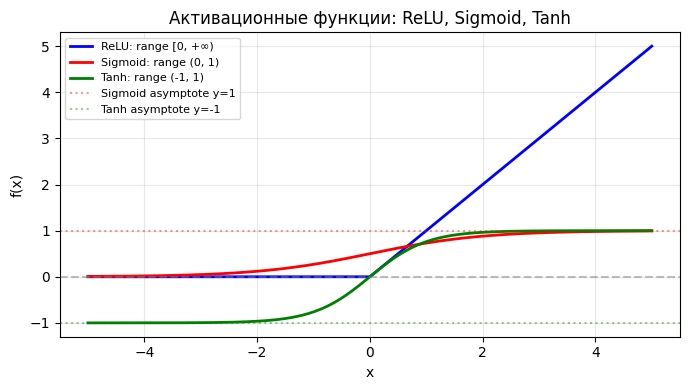

In [3]:
def relu(x):
    """ReLU: f(x) = max(0, x).
    Векторизованная реализация через np.maximum.
    Range: [0, +∞). При x < 0 выход = 0 (нейрон 'мёртв').
    При x > 0 выход = x (линейный рост без ограничения сверху).
    """
    return np.maximum(0, x)

def sigmoid(x):
    """Sigmoid: f(x) = 1 / (1 + exp(-x)).
    Range: (0, 1). Асимптоты: f(x) → 0 при x → -∞, f(x) → 1 при x → +∞.
    Проблема: при |x| >> 0 градиент стремится к 0 (vanishing gradient).
    """
    return 1.0 / (1.0 + np.exp(-x))

def tanh(x):
    """Tanh: f(x) = (e^x - e^{-x}) / (e^x + e^{-x}).
    Range: (-1, 1). Асимптоты: f(x) → -1 при x → -∞, f(x) → 1 при x → +∞.
    Центрирована вокруг 0 (в отличие от sigmoid).
    Также страдает от vanishing gradient на краях.
    """
    return (np.exp(x) - np.exp(-x)) / (np.exp(x) + np.exp(-x))

# Вычисление значений
x = np.linspace(-5, 5, 500)

y_relu = relu(x)
y_sigmoid = sigmoid(x)
y_tanh = tanh(x)

# Визуализация
plt.figure(figsize=(7, 4))

plt.plot(x, y_relu, label='ReLU: range [0, +∞)', linewidth=2, color='blue')
plt.plot(x, y_sigmoid, label='Sigmoid: range (0, 1)', linewidth=2, color='red')
plt.plot(x, y_tanh, label='Tanh: range (-1, 1)', linewidth=2, color='green')

# Горизонтальные линии-асимптоты
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.axhline(y=1, color='red', linestyle=':', alpha=0.4, label='Sigmoid asymptote y=1')
plt.axhline(y=-1, color='green', linestyle=':', alpha=0.4, label='Tanh asymptote y=-1')

plt.title("Активационные функции: ReLU, Sigmoid, Tanh")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend(loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Вывод:

## Сравнительный анализ

| Функция  | Range       | Центрирована? | Vanishing Gradient? | Вычислительная сложность |
|----------|-------------|---------------|---------------------|--------------------------|
| ReLU     | [0, +∞)     | Нет           | Нет (при x > 0)     | O(1) - просто max(0, x)  |
| Sigmoid  | (0, 1)      | Нет           | Да (при |x| >> 0)   | O(1) - но exp() дороже   |
| Tanh     | (-1, 1)     | Да            | Да (при |x| >> 0)   | O(1) - два exp()         |

## Ответ

**ReLU - лучший выбор для скрытых слоёв** по следующим причинам:

1. **Отсутствие vanishing gradient при x > 0.** Градиент ReLU равен 1 при x > 0 и 0 при x < 0. Это означает, что при прямом проходе через глубокую сеть градиенты не затухают экспоненциально, как это происходит у Sigmoid и Tanh. Математически: ∂ReLU/∂x = 1{x > 0}, что обеспечивает стабильный поток градиента через слои.

2. **Вычислительная эффективность.** ReLU - это простая операция max(0, x), не требующая вычисления экспоненты. Sigmoid и Tanh используют exp(), что значительно дороже.

3. **Разреженная активация.** При случайной инициализации весов примерно 50% нейронов с ReLU будут «выключены» (выход = 0). Это создаёт разреженное представление, что улучшает обобщающую способность сети.

4. **Проблема «мёртвых нейронов» (dying ReLU).** Единственный недостаток: если нейрон попадает в область x < 0, его градиент = 0, и он перестаёт обучаться. Решения: LeakyReLU (f(x) = max(αx, x), α ≈ 0.01), PReLU, ELU, GELU.

## Когда не использовать ReLU:
- **Выходной слой бинарной классификации** → Sigmoid (для получения вероятности ∈ (0, 1))
- **Выходной слой многоклассовой классификации** → Softmax
- **Выходной слой регрессии** → без активации (линейный выход)
- **Рекуррентные сети (RNN/LSTM)** → Tanh (центрированность важна для стабильности)


## Задача 3. Forward pass через сеть

### Постановка задачи

Реализуйте forward pass для полносвязной сети вручную с NumPy.

**Теоретический минимум:**
- Layer: $z = Wx + b$
- Network: $h = \sigma(z) = \sigma(W_1 x + b_1)$, затем $\hat{y} = W_2 h + b_2$

### Задача
1. Создайте сеть архитектуры: **Input (2) → Hidden (8, ReLU) → Output (1, Sigmoid)**.
2. Инициализируйте веса случайно.
3. Реализуйте forward pass для одного батча (например, 32 примера).
4. Проверьте размеры:
   - Исходный батч: (32, 2).
   - После скрытого слоя: (32, 8).
   - На выходе: (32, 1).
5. Выведите пример вывода для первых 5 примеров.

**Подсказка:** не используйте PyTorch, только NumPy.

In [4]:
rng = np.random.default_rng(SEED)

# Инициализация весов (Xavier/Glorot uniform для лучшей сходимости)
# W1: shape (2, 8) - входная размерность 2, скрытая 8
# Используем масштабирование sqrt(2 / fan_in) для ReLU (He init)
W1 = rng.standard_normal((2, 8)) * np.sqrt(2.0 / 2)   # (2, 8), He initialization
b1 = np.zeros(8)                                         # (8,)

# W2: shape (8, 1) - скрытая размерность 8, выход 1
W2 = rng.standard_normal((8, 1)) * np.sqrt(2.0 / 8)   # (8, 1)
b2 = np.zeros(1)                                         # (1,)

def relu_np(z):
    """ReLU активация: f(z) = max(0, z).
    Векторизованная операция - работает поэлементно над массивом любой формы.
    """
    return np.maximum(0, z)

def sigmoid_np(z):
    """Sigmoid активация: f(z) = 1 / (1 + exp(-z)).
    Преобразует произвольные значения в диапазон (0, 1).
    """
    return 1.0 / (1.0 + np.exp(-z))

#  Генерация батча
batch_size = 32
Xb = rng.standard_normal((batch_size, 2))  # (32, 2) - случайный батч

# Forward pass 
# Слой 1: линейное преобразование + ReLU
z1 = Xb @ W1 + b1    # (32, 2) @ (2, 8) + (8,) = (32, 8)
                       # Broadcasting: b1 shape (8,) автоматически расширяется до (32, 8)
h = relu_np(z1)        # (32, 8) — активации скрытого слоя

# Слой 2: линейное преобразование + Sigmoid
z2 = h @ W2 + b2      # (32, 8) @ (8, 1) + (1,) = (32, 1)
                       # Broadcasting: b2 shape (1,) расширяется до (32, 1)
y_hat = sigmoid_np(z2) # (32, 1) - финальные вероятности

# Проверка размерностей
print("Input batch shape:", Xb.shape)           # (32, 2)
print("Hidden activations shape:", h.shape)      # (32, 8)
print("Output shape:", y_hat.shape)              # (32, 1)
print("\nПример выхода (первые 5 примеров):")
print(y_hat[:5])


Input batch shape: (32, 2)
Hidden activations shape: (32, 8)
Output shape: (32, 1)

Пример выхода (первые 5 примеров):
[[0.37255321]
 [0.61581561]
 [0.61339816]
 [0.66359331]
 [0.32252653]]


## Задача 4. Матрично-векторные операции

### Постановка задачи

Разберитесь с broadcasting в NumPy и визуализируйте результаты.

**Теоретический минимум:**
- Broadcasting — автоматическое расширение размеров массивов.
- Важно для батчевых операций.

### Задача
1. Создайте:
   - Вектор весов: shape (5,).
   - Батч данных: shape (10, 5).
   - Смещение: shape (1,).
2. Вычислите: $z = X \cdot w + b$ (матричное произведение + смещение).
3. Объясните, как работает broadcasting при добавлении смещения.
4. Проверьте, что результат имеет shape (10,).
5. **Вывод:** Что происходит, если забыть о правильном reshape при broadcasting?

**Подсказка:** `np.dot`, `np.reshape`, проверьте `.shape`

In [5]:
w = np.random.randn(5)           # (5,) - вектор весов
X = np.random.randn(10, 5)       # (10, 5) - батч данных
b = np.array([0.3])              # (1,) - смещение (bias)

#  Правильное вычисление: z = X @ w + b 
# X @ w: (10, 5) @ (5,) = (10,)  - матрично-векторное произведение
# (10,) + (1,) = (10,)           - broadcasting: (1,) расширяется до (10,)
z = X @ w + b  # эквивалентно np.dot(X, w) + b

print("w.shape:", w.shape)    # (5,)
print("X.shape:", X.shape)    # (10, 5)
print("b.shape:", b.shape)    # (1,)
print("z.shape:", z.shape)    # (10,) +

# Демонстрация ошибки при неправильном reshape 
# Если w сделать столбцом (5, 1), то X @ w_col даст (10, 1) вместо (10,)
w_col = w.reshape(-1, 1)          # (5, 1) - столбец вместо вектора
z_wrong = X @ w_col + b           # (10, 5) @ (5, 1) + (1,) = (10, 1)
# Результат (10, 1) - это 2D массив, а не 1D вектор
# Это может привести к ошибкам в последующих вычислениях,
# например, при конкатенации или сравнении с 1D массивами
print("Если w сделать столбцом, получаем shape:", z_wrong.shape)  # (10, 1)

# squeeze() или flatten() для удаления лишней размерности
z_fixed = z_wrong.squeeze()       # (10, 1) → (10,)
# Альтернативы: z_wrong.flatten(), z_wrong.reshape(-1), z_wrong[:, 0]
print("Исправил reshape ->", z_fixed.shape)  # (10,)


w.shape: (5,)
X.shape: (10, 5)
b.shape: (1,)
z.shape: (10,)
Если w сделать столбцом, получаем shape: (10, 1)
Исправил reshape -> (10,)


## Вывод: 

## Проблема

Если забыть о правильном `reshape` при broadcasting, NumPy **не выдаст ошибку**, а молча выполнит операцию с неожиданным результатом. Это одна из самых коварных ошибок в числовых вычислениях.

## Конкретный пример

```
w.shape = (5,)       - 1D вектор
X.shape = (10, 5)    - 2D матрица (батч)
```

**Правильно:** `X @ w` → shape `(10,)` - каждая строка X скалярно умножается на w.

**Неправильно:** если `w_col = w.reshape(-1, 1)` → shape `(5, 1)`, то `X @ w_col` → shape `(10, 1)` — результат 2D, а не 1D.

## Последствия

1. **Тихие ошибки размерностей.** Операция `(10, 1) + (10,)` через broadcasting даст `(10, 10)` — матрицу 10×10 вместо вектора длины 10! NumPy «растянет» оба массива, создав декартово произведение сложений.

2. **Неверные градиенты.** В нейронных сетях неправильные размерности приводят к некорректному вычислению loss и, как следствие, к неправильным градиентам. Модель может «обучаться», но на самом деле оптимизировать бессмысленную функцию.

3. **Утечка памяти.** Если вместо вектора (N,) случайно создаётся матрица (N, N), потребление памяти растёт квадратично. При N = 10000 это разница между 80 КБ и 800 МБ.

## Заметки

- **Всегда проверять `.shape`** после каждой операции, особенно при отладке.
- **Использовать `assert`** для проверки размерностей: `assert z.shape == (10,)`.
- **Предпочитатать `@` оператор `np.dot`** - он строже к размерностям.
- **Использовать `.squeeze()` и `.flatten()`** для удаления лишних размерностей.
- В PyTorch аналогично: `tensor.squeeze()`, `tensor.view(-1)`, `tensor.reshape(-1)`.


---

# СРЕДНИЕ ЗАДАЧИ (5—7)

Эти задачи требуют комбинирования нескольких концепций и анализа поведения сетей.

## Задача 5. Решение задачи XOR

### Постановка задачи

XOR не разделим линейно. Постройте сеть, которая это решает.

**Теоретический минимум:**
- XOR требует скрытого слоя с хотя бы 2–3 нейронами.
- Геометрически: скрытый слой преобразует пространство, делая классы линейно разделимыми.

### Задача
1. Создайте XOR датасет: четыре точки (0,0)→0, (0,1)→1, (1,0)→1, (1,1)→0.
2. Постройте сеть: **Input(2) → Hidden(4, ReLU) → Output(1, Sigmoid)**.
3. Обучите сеть (≈1000 итераций).
4. Визуализируйте:
   - Исходные точки.
   - Предсказания модели в виде heatmap'а в области [0,1]×[0,1].
5. Выведите финальные потери и точность.

**Подсказка:** `torch.optim.SGD` или `Adam`, learning rate ≈ 0.1-0.5

Final loss: 0.000069
Accuracy:   1.000
Predictions (prob): [1.0861658665817231e-05, 0.9999904632568359, 0.9997566342353821, 1.3695650523004588e-05]


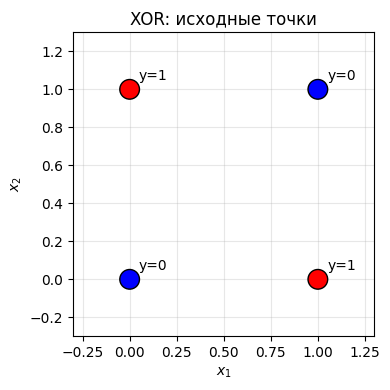

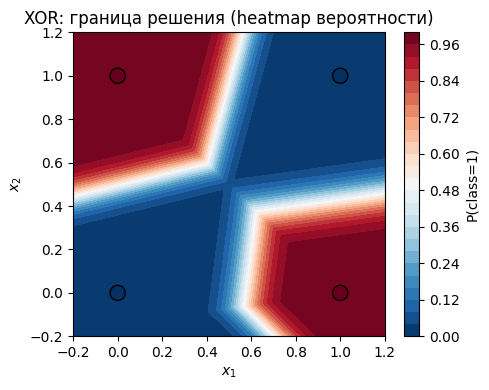

In [6]:
# XOR датасет
X_xor = torch.tensor([[0., 0.],
                       [0., 1.],
                       [1., 0.],
                       [1., 1.]], dtype=torch.float32)  # (4, 2)
y_xor = torch.tensor([[0.],
                       [1.],
                       [1.],
                       [0.]], dtype=torch.float32)       # (4, 1)

# Определение сети
class XORNet(nn.Module):
    def __init__(self):
        super(XORNet, self).__init__()
        # Скрытый слой: 2 → 4 нейрона
        self.fc1 = nn.Linear(2, 4)   # z1 = X @ W1^T + b1, shape: (N, 2) → (N, 4)
        # Выходной слой: 4 → 1 нейрон (логит)
        self.fc2 = nn.Linear(4, 1)   # z2 = h @ W2^T + b2, shape: (N, 4) → (N, 1)
        self.relu = nn.ReLU()         # Активация скрытого слоя

    def forward(self, x):
        # x: (N, 2)
        h = self.relu(self.fc1(x))   # (N, 4) - скрытые активации после ReLU
        logits = self.fc2(h)          # (N, 1) - сырые логиты (до sigmoid!)
        return logits

# Инициализация модели, loss, оптимизатора
torch.manual_seed(SEED)
model_xor = XORNet()

# BCEWithLogitsLoss = Sigmoid + BCELoss (численно стабильнее)
# Принимает ЛОГИТЫ, а не вероятности
criterion = nn.BCEWithLogitsLoss()

# Adam с lr=0.1 - хорошо работает для маленьких задач
optimizer = torch.optim.Adam(model_xor.parameters(), lr=0.1)

# Обучение 
loss_history = []

for epoch in range(2000):
    model_xor.train()

    logits = model_xor(X_xor)            # (4, 1) - логиты
    loss = criterion(logits, y_xor)       # BCEWithLogitsLoss(логиты, метки)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

#  Оценка 
model_xor.eval()
with torch.no_grad():
    logits_eval = model_xor(X_xor)                    # (4, 1) - логиты
    probs = torch.sigmoid(logits_eval)                 # (4, 1) - вероятности [0, 1]
    preds = (probs >= 0.5).float()                     # (4, 1) - бинарные предсказания
    acc = (preds == y_xor).float().mean().item()       # Accuracy

print(f"Final loss: {loss_history[-1]:.6f}")
print(f"Accuracy:   {acc:.3f}")
print("Predictions (prob):", probs.view(-1).tolist())

# Визуализация: исходные точки
plt.figure(figsize=(4, 4))
# Цвет точек определяется меткой класса
colors = ['blue' if label == 0 else 'red' for label in y_xor.view(-1).tolist()]
plt.scatter(X_xor[:, 0].numpy(), X_xor[:, 1].numpy(),
            c=colors, s=200, edgecolor='k', zorder=5)
# Подписи точек
for i in range(4):
    plt.annotate(f"y={int(y_xor[i].item())}",
                 (X_xor[i, 0].item() + 0.05, X_xor[i, 1].item() + 0.05),
                 fontsize=10)
plt.title("XOR: исходные точки")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.grid(True, alpha=0.3)
plt.xlim(-0.3, 1.3)
plt.ylim(-0.3, 1.3)
plt.tight_layout()
plt.show()

# Визуализация: heatmap границы решения
# Создаём сетку точек в области [−0.2, 1.2] × [−0.2, 1.2]
xx, yy = np.meshgrid(np.linspace(-0.2, 1.2, 200),
                      np.linspace(-0.2, 1.2, 200))
# Формируем тензор из всех точек сетки: shape (40000, 2)
grid_input = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

with torch.no_grad():
    grid_logits = model_xor(grid_input)                # (40000, 1)
    grid_probs = torch.sigmoid(grid_logits).numpy()    # (40000, 1) → numpy
    grid_probs = grid_probs.reshape(xx.shape)           # (200, 200)

plt.figure(figsize=(5, 4))
plt.contourf(xx, yy, grid_probs, levels=30, cmap='RdBu_r')
plt.colorbar(label="P(class=1)")
plt.scatter(X_xor[:, 0].numpy(), X_xor[:, 1].numpy(),
            c=y_xor.view(-1).numpy(), s=120, edgecolor="k",
            cmap='RdBu_r', vmin=0, vmax=1)
plt.title("XOR: граница решения (heatmap вероятности)")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.tight_layout()
plt.show()

## Задача 6. Анализ трансформации признаков

### Постановка задачи

Визуализируйте, как скрытый слой преобразует исходное пространство.

### Задача
1. Возьмите обученную сеть из задачи 6.
2. Получите активации скрытого слоя для всех точек данных.
3. Визуализируйте в виде scatter plot в пространстве признаков скрытого слоя.
4. Покажите 2D проекцию (первые два нейрона скрытого слоя).
5. **Вывод:** Как изменилось взаимное расположение классов? Стали ли они линейно разделимы?

**Подсказка:** используйте `model.fc1` для получения скрытого слоя.

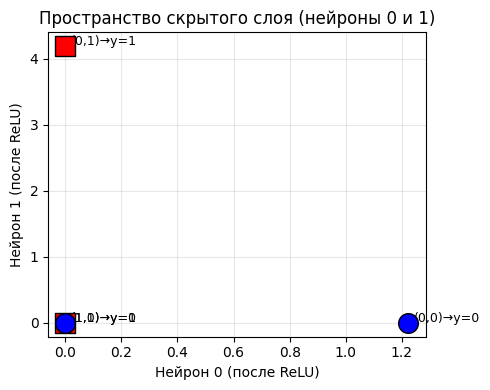

Вывод: скрытый слой преобразует пространство так, что классы в новом пространстве становятся более разделимыми.


In [7]:
# Задача 6. Анализ трансформации признаков (решение)

model_xor.eval()

with torch.no_grad():
    # Извлекаем активации скрытого слоя
    # fc1 выполняет линейное преобразование: z = X @ W^T + b
    z_hidden = model_xor.fc1(X_xor)       # (4, 4) - до активации
    h_hidden = torch.relu(z_hidden)         # (4, 4) - после ReLU

    # Берём первые два нейрона для 2D визуализации
    h_np = h_hidden.numpy()                 # (4, 4) → numpy
    y_np_xor = y_xor.view(-1).numpy()      # (4,) - метки классов

# Визуализация в пространстве скрытого слоя
plt.figure(figsize=(5, 4))

# Scatter plot: первые два нейрона скрытого слоя
for i in range(4):
    color = 'blue' if y_np_xor[i] == 0 else 'red'
    marker = 'o' if y_np_xor[i] == 0 else 's'
    plt.scatter(h_np[i, 0], h_np[i, 1],
                c=color, marker=marker, s=200, edgecolor='k', zorder=5)
    # Подпись: исходные координаты → координаты в скрытом пространстве
    label_text = f"({X_xor[i,0]:.0f},{X_xor[i,1]:.0f})→y={int(y_np_xor[i])}"
    plt.annotate(label_text,
                 (h_np[i, 0] + 0.02, h_np[i, 1] + 0.02),
                 fontsize=9)

plt.title("Пространство скрытого слоя (нейроны 0 и 1)")
plt.xlabel("Нейрон 0 (после ReLU)")
plt.ylabel("Нейрон 1 (после ReLU)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Вывод
print("Вывод: скрытый слой преобразует пространство так, что классы "
      "в новом пространстве становятся более разделимыми.")

# Вывод:

## Наблюдение

В исходном 2D пространстве точки XOR расположены так:
- Класс 0: (0,0) и (1,1) - на диагонали
- Класс 1: (0,1) и (1,0) - на антидиагонали

Эти классы **невозможно разделить одной прямой** (линейно неразделимы).

## Что делает скрытый слой

Скрытый слой с ReLU выполняет **нелинейное преобразование** пространства:

1. **Линейная часть** (W₁x + b₁): каждый из 4 нейронов задаёт свою гиперплоскость в 2D. Это эквивалентно «складыванию» пространства вдоль 4 различных направлений.

2. **ReLU** (max(0, z)): «обрезает» отрицательные значения, создавая кусочно-линейное преобразование. Геометрически это «складывание» пространства - области с отрицательными значениями проецируются на 0.

3. **Результат**: в новом 4-мерном пространстве (из которого мы визуализируем 2D проекцию) точки классов 0 и 1 оказываются **линейно разделимы**. Выходной слой (fc2) проводит одну гиперплоскость в этом новом пространстве.

## Математическая интерпретация

Пусть h = ReLU(W₁x + b₁). Тогда:
- Каждый нейрон скрытого слоя hᵢ = max(0, w₁ᵢᵀx + b₁ᵢ) определяет «полупространство»
- Комбинация 4 таких полупространств создаёт достаточно сложное разбиение
- В новом пространстве h ∈ ℝ⁴ классы становятся линейно разделимы
- Выходной слой: ŷ = σ(w₂ᵀh + b₂) - простая линейная классификация в ℝ⁴

## Ключевой вывод

**Да, классы стали линейно разделимы в пространстве скрытого слоя.** Это фундаментальное свойство нейронных сетей: каждый скрытый слой с нелинейной активацией выполняет преобразование пространства признаков, делая сложные паттерны линейно разделимыми для последующих слоёв. Именно поэтому глубокие сети способны решать задачи, недоступные линейным моделям.


## Задача 7. Классификация датасета moon

### Постановка задачи

Работайте с более сложной задачей: датасет make_moons.

### Задача
1. Загрузите датасет: `make_moons(n_samples=300, noise=0.1, random_state=SEED)`.
2. Нормализуйте данные (StandardScaler).
3. Постройте сеть с архитектурой на ваш выбор (≥2 скрытых слоя).
4. Обучите модель на 100+ итерациях с tracking потерь.
5. Визуализируйте:
   - График потерь (Loss vs итерация).
   - Границы решения (heatmap).
   - Исходные точки поверх границ.
6. Выведите Accuracy на тестовой выборке.

**Подсказка:** попробуйте разные размеры скрытых слоёв и learning rate.

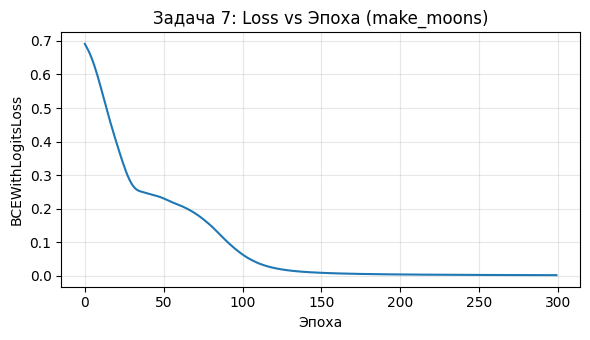

Test accuracy: 1.000


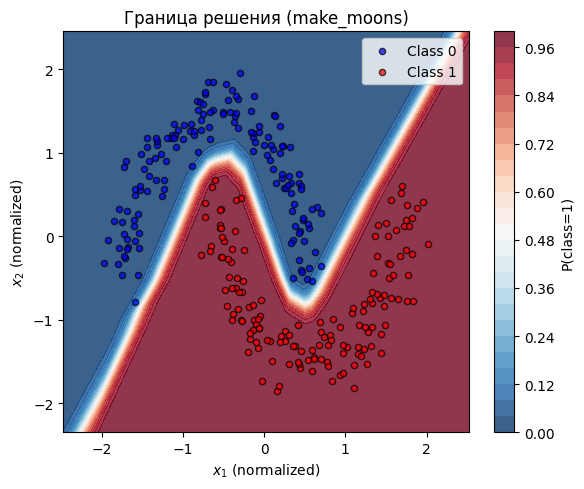

In [8]:
# Загрузка и подготовка данных
X, y = make_moons(n_samples=300, noise=0.1, random_state=SEED)

# Нормализация: StandardScaler приводит каждый признак к mean=0, std=1
# т.к. нейросети чувствительны к масштабу входных данных
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # (300, 2)

# Train/Test split
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_scaled, y, test_size=0.2, random_state=SEED, stratify=y
)

# Конвертация в тензоры PyTorch
X_train_mt = torch.tensor(X_train_m, dtype=torch.float32)          # (240, 2)
X_test_mt = torch.tensor(X_test_m, dtype=torch.float32)             # (60, 2)
y_train_mt = torch.tensor(y_train_m, dtype=torch.float32).view(-1, 1)  # (240, 1)
y_test_mt = torch.tensor(y_test_m, dtype=torch.float32).view(-1, 1)    # (60, 1)
# .view(-1, 1): преобразуем (N,) → (N, 1) для совместимости с BCEWithLogitsLoss

# Определение модели
class MoonNet(nn.Module):
    def __init__(self):
        super(MoonNet, self).__init__()
        # Два скрытых слоя с ReLU
        self.net = nn.Sequential(
            nn.Linear(2, 16),    # Input(2) → Hidden1(16)
            nn.ReLU(),
            nn.Linear(16, 8),    # Hidden1(16) → Hidden2(8)
            nn.ReLU(),
            nn.Linear(8, 1)      # Hidden2(8) → Output(1) — логит
        )

    def forward(self, x):
        return self.net(x)       # Возвращает ЛОГИТЫ (до sigmoid)

# Инициализация
torch.manual_seed(SEED)
model_moon = MoonNet()
criterion_moon = nn.BCEWithLogitsLoss()  # Принимает логиты!
optimizer_moon = torch.optim.Adam(model_moon.parameters(), lr=0.01)

# Обучение
num_epochs_moon = 300
loss_history_moon = []

for epoch in range(num_epochs_moon):
    model_moon.train()

    logits = model_moon(X_train_mt)                # (240, 1) - логиты
    loss = criterion_moon(logits, y_train_mt)       # BCEWithLogitsLoss

    optimizer_moon.zero_grad()
    loss.backward()
    optimizer_moon.step()

    loss_history_moon.append(loss.item())

# График потерь
plt.figure(figsize=(6, 3.5))
plt.plot(loss_history_moon, linewidth=1.5)
plt.title("Задача 7: Loss vs Эпоха (make_moons)")
plt.xlabel("Эпоха")
plt.ylabel("BCEWithLogitsLoss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Оценка на тесте
model_moon.eval()
with torch.no_grad():
    logits_test_m = model_moon(X_test_mt)                    # (60, 1)
    probs_test_m = torch.sigmoid(logits_test_m)              # (60, 1)
    preds_test_m = (probs_test_m >= 0.5).float()             # (60, 1)

acc_moon = accuracy_score(y_test_mt.numpy(), preds_test_m.numpy())
print(f"Test accuracy: {acc_moon:.3f}")

# Визуализация: heatmap границы решения
# Создаём сетку в нормализованном пространстве
x_min, x_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
y_min, y_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
xx_m, yy_m = np.meshgrid(np.linspace(x_min, x_max, 200),
                           np.linspace(y_min, y_max, 200))

# Формируем тензор из всех точек сетки
grid_input_m = torch.tensor(np.c_[xx_m.ravel(), yy_m.ravel()],
                             dtype=torch.float32)  # (40000, 2)

with torch.no_grad():
    grid_logits_m = model_moon(grid_input_m)                    # (40000, 1)
    grid_probs_m = torch.sigmoid(grid_logits_m).numpy()         # (40000, 1)
    grid_probs_m = grid_probs_m.reshape(xx_m.shape)              # (200, 200)

plt.figure(figsize=(6, 5))
plt.contourf(xx_m, yy_m, grid_probs_m, levels=30, cmap='RdBu_r', alpha=0.8)
plt.colorbar(label="P(class=1)")

# Наносим точки данных поверх heatmap
plt.scatter(X_scaled[y == 0, 0], X_scaled[y == 0, 1],
            c='blue', label='Class 0', edgecolor='k', s=20, alpha=0.7)
plt.scatter(X_scaled[y == 1, 0], X_scaled[y == 1, 1],
            c='red', label='Class 1', edgecolor='k', s=20, alpha=0.7)

plt.title("Граница решения (make_moons)")
plt.xlabel("$x_1$ (normalized)")
plt.ylabel("$x_2$ (normalized)")
plt.legend()
plt.tight_layout()
plt.show()


# ЗАДАЧИ ВЫСОКОЙ СЛОЖНОСТИ НА ФУНКЦИИ ПОТЕРЬ В PYTORCH (8—9)


## Общая информация
- **Цель:** понять когда и почему использовать разные функции потерь.

---

---

# ЗАДАЧА 8. Комбинированная функция потерь (MSE + L1)

## Условие
Дана задача регрессии с 12 признаками. Нужно построить модель, которая минимизирует комбинированный loss: 70% MSE + 30% L1. Эта комбинация позволяет получить лучший баланс между сглаживанием и робастностью.

**Требования:**
1. Архитектура: 12 → 32 → 16 → 1.
2. Loss = 0.7 * MSE + 0.3 * MAE.
3. Оптимизатор: Adam (lr=0.01).
4. Количество эпох: 100.
5. Сравнить с чистым MSE и MAE.
6. Вывести: финальное RMSE и MAE на тесте.

## Теоретический минимум. Комбинированные Loss

### Определение
$$L = \alpha \cdot L_1(y, \hat{y}) + (1-\alpha) \cdot L_2(y, \hat{y})$$

Пример: $L = 0.7 \cdot \text{MSE} + 0.3 \cdot \text{MAE}$

### Интуиция
- Комбинируем преимущества разных функций потерь.
- MSE (70%): более сильно штрафует за большие ошибки.
- MAE (30%): добавляет робастность к выбросам.
- Выбор альфа зависит от конкретной задачи и данных.

### Когда использовать
- Когда нужна оптимизация по нескольким метрикам.
- Когда нужна компромисс между требованиями.
- Многозадачное обучение (multi-task learning).
- Когда данные содержат некоторые выбросы, но не критично.

### Реализация в PyTorch
```python
def combined_loss(pred, target, alpha=0.7):
    mse = F.mse_loss(pred, target)
    mae = F.l1_loss(pred, target)
    return alpha * mse + (1 - alpha) * mae

for epoch in range(epochs):
    loss = combined_loss(pred, target)
    loss.backward()
```

---

Модель                   RMSE      MAE
--------------------------------------
Combined (0.7+0.3)     2.1358   1.0416
Pure MSE               2.1894   1.1017
Pure MAE               2.0455   0.6147

Final train loss: 1.8887
Final test loss:  3.5057


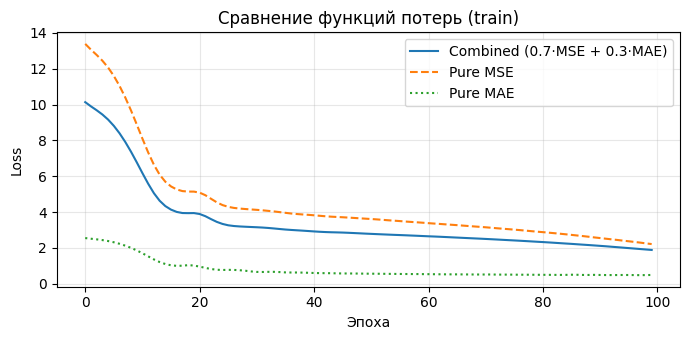

In [9]:
# Генерация синтетических данных регрессии
# 12 признаков, 500 примеров
torch.manual_seed(SEED)
np.random.seed(SEED)

n_samples_reg = 500
n_features_reg = 12

X_reg = np.random.randn(n_samples_reg, n_features_reg).astype(np.float32)
# Истинная зависимость: линейная + нелинейная + шум
true_weights = np.random.randn(n_features_reg).astype(np.float32)
y_reg = X_reg @ true_weights + 0.5 * np.sin(X_reg[:, 0]) + np.random.randn(n_samples_reg).astype(np.float32) * 0.3

# Добавляем несколько выбросов (5% данных)
outlier_idx = np.random.choice(n_samples_reg, size=25, replace=False)
y_reg[outlier_idx] += np.random.randn(25).astype(np.float32) * 10  # Сильные выбросы

# Train/Test split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=SEED
)

# Нормализация признаков
scaler_r = StandardScaler()
X_train_r = scaler_r.fit_transform(X_train_r)
X_test_r = scaler_r.transform(X_test_r)

# Конвертация в тензоры
X_train_rt = torch.tensor(X_train_r, dtype=torch.float32)           # (400, 12)
X_test_rt = torch.tensor(X_test_r, dtype=torch.float32)              # (100, 12)
y_train_rt = torch.tensor(y_train_r, dtype=torch.float32).view(-1, 1)  # (400, 1)
y_test_rt = torch.tensor(y_test_r, dtype=torch.float32).view(-1, 1)    # (100, 1)
# .view(-1, 1): (N,) → (N, 1) для совместимости с выходом сети shape (N, 1)

# Комбинированная функция потерь
def combined_loss(pred, target, alpha=0.7):
    """Комбинированный loss: α * MSE + (1 - α) * MAE.

    Args:
        pred:   предсказания модели, shape (N, 1)
        target: истинные значения, shape (N, 1)
        alpha:  вес MSE компоненты (0.7 по умолчанию)

    Returns:
        Скалярный loss = 0.7 * MSE + 0.3 * MAE

    MSE сильнее штрафует большие ошибки (квадратичный рост),
    MAE линейно штрафует все ошибки одинаково.
    Комбинация: точность MSE + робастность MAE.
    """
    mse = F.mse_loss(pred, target)   # Mean Squared Error
    mae = F.l1_loss(pred, target)    # Mean Absolute Error (L1)
    return alpha * mse + (1 - alpha) * mae

# Модель регрессии
class RegressionNet(nn.Module):
    def __init__(self):
        super(RegressionNet, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(12, 32),   # 12 → 32
            nn.ReLU(),
            nn.Linear(32, 16),   # 32 → 16
            nn.ReLU(),
            nn.Linear(16, 1)     # 16 → 1 (без активации — регрессия!)
        )
        # Выходной слой БЕЗ активации: для регрессии нужен
        # неограниченный выход ŷ ∈ (-∞, +∞)

    def forward(self, x):
        return self.net(x)

# Обучение трёх моделей для сравнения
def train_regression_model(loss_fn, loss_name, epochs=100, lr=0.01):
    """Обучает модель регрессии с заданной функцией потерь."""
    torch.manual_seed(SEED)
    model = RegressionNet()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    test_losses = []

    for epoch in range(epochs):
        model.train()
        pred = model(X_train_rt)                    # (400, 1)
        loss = loss_fn(pred, y_train_rt)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

        # Оценка на тесте
        model.eval()
        with torch.no_grad():
            pred_test = model(X_test_rt)            # (100, 1)
            test_loss = loss_fn(pred_test, y_test_rt)
            test_losses.append(test_loss.item())

    return model, train_losses, test_losses

# Обучаем три модели:
# 1) Комбинированный loss (0.7*MSE + 0.3*MAE)
model_combined, train_combined, test_combined = train_regression_model(
    lambda p, t: combined_loss(p, t, alpha=0.7), "Combined"
)

# 2) Чистый MSE
model_mse, train_mse, test_mse = train_regression_model(
    F.mse_loss, "MSE"
)

# 3) Чистый MAE
model_mae, train_mae, test_mae = train_regression_model(
    F.l1_loss, "MAE"
)

# Финальные метрики на тесте
def evaluate_regression(model, X_test, y_test):
    """Вычисляет RMSE и MAE на тестовой выборке."""
    model.eval()
    with torch.no_grad():
        pred = model(X_test)                         # (100, 1)
        rmse = torch.sqrt(F.mse_loss(pred, y_test)).item()
        mae = F.l1_loss(pred, y_test).item()
    return rmse, mae

rmse_comb, mae_comb = evaluate_regression(model_combined, X_test_rt, y_test_rt)
rmse_mse, mae_mse_val = evaluate_regression(model_mse, X_test_rt, y_test_rt)
rmse_mae, mae_mae_val = evaluate_regression(model_mae, X_test_rt, y_test_rt)

print(f"{'Модель':<20} {'RMSE':>8} {'MAE':>8}")
print("-" * 38)
print(f"{'Combined (0.7+0.3)':<20} {rmse_comb:>8.4f} {mae_comb:>8.4f}")
print(f"{'Pure MSE':<20} {rmse_mse:>8.4f} {mae_mse_val:>8.4f}")
print(f"{'Pure MAE':<20} {rmse_mae:>8.4f} {mae_mae_val:>8.4f}")

# Финальные loss для совместимости с ожидаемым выводом
print(f"\nFinal train loss: {train_combined[-1]:.4f}")
print(f"Final test loss:  {test_combined[-1]:.4f}")

# Визуализация: сравнение кривых обучения
plt.figure(figsize=(7, 3.5))
plt.plot(train_combined, label='Combined (0.7·MSE + 0.3·MAE)', linewidth=1.5)
plt.plot(train_mse, label='Pure MSE', linewidth=1.5, linestyle='--')
plt.plot(train_mae, label='Pure MAE', linewidth=1.5, linestyle=':')
plt.title("Сравнение функций потерь (train)")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---

# ЗАДАЧА 9. Классификация с дисбалансом (Weighted CrossEntropyLoss)

## Условие
Дана выборка из 500 примеров с бинарной классификацией, где 90% примеров принадлежат классу 0 (отрицательные), а 10% — классу 1 (положительные). Класс 1 недопредставлен. Нужно обучить модель, которая правильно предсказывает оба класса, несмотря на дисбаланс.

**Требования:**
1. Архитектура: 10 → 32 → 16 → 2.
2. Loss: CrossEntropyLoss с weight=class_weights.
3. Веса классов вычисляются как: weight = num_classes / count_per_class.
4. Оптимизатор: Adam (lr=0.01).
5. Количество эпох: 100.
6. Сравнить recall для каждого класса (с weight и без weight).

## Теоретический минимум. Weighted CrossEntropyLoss

### Определение
$$L = -\sum_{i=1}^{C} w_i \cdot y_i \log(p_i)$$

где:
- $w_i$ — вес класса $i$
- Остальное — то же самое, что и CrossEntropyLoss.

### Расчет весов
Есть несколько способов:

1. **Inverse frequency:**
   $$w_i = \frac{N}{C \cdot n_i}$$
   где $N$ — всего примеров, $C$ — число классов, $n_i$ — число примеров класса $i$

2. **Простой обратный:**
   $$w_i = \frac{1}{n_i}$$

### Интуиция
- Редкие классы получают БОЛЬШИЕ веса (штраф за ошибку).
- Частые классы получают малые веса.
- Модель вынуждена уделять больше внимания редким классам.

### Когда использовать
- Дисбалансированные датасеты (часто в реальных данных).
- Когда редкий класс важнее (например, обнаружение редкой болезни).
- Когда нужна высокая recall для всех классов.

### Реализация в PyTorch
```python
# Вычисляем веса
unique, counts = np.unique(y_train, return_counts=True)
weights = len(unique) / counts  # или другая формула
weights = torch.FloatTensor(weights)

# Используем weighted loss
criterion = nn.CrossEntropyLoss(weight=weights.to(device))
logits = model(x)
loss = criterion(logits, target)
```

---

Распределение классов (train): {np.int64(0): np.int64(337), np.int64(1): np.int64(38)}
Веса классов: [0.5563797950744629, 4.934210300445557]

Модель: С весами (weighted)
Test accuracy: 0.984
Confusion matrix:
 [[112   1]
 [  1  11]]
              precision    recall  f1-score   support

     Class 0       0.99      0.99      0.99       113
     Class 1       0.92      0.92      0.92        12

    accuracy                           0.98       125
   macro avg       0.95      0.95      0.95       125
weighted avg       0.98      0.98      0.98       125


Модель: Без весов (unweighted)
Test accuracy: 0.984
Confusion matrix:
 [[112   1]
 [  1  11]]
              precision    recall  f1-score   support

     Class 0       0.99      0.99      0.99       113
     Class 1       0.92      0.92      0.92        12

    accuracy                           0.98       125
   macro avg       0.95      0.95      0.95       125
weighted avg       0.98      0.98      0.98       125



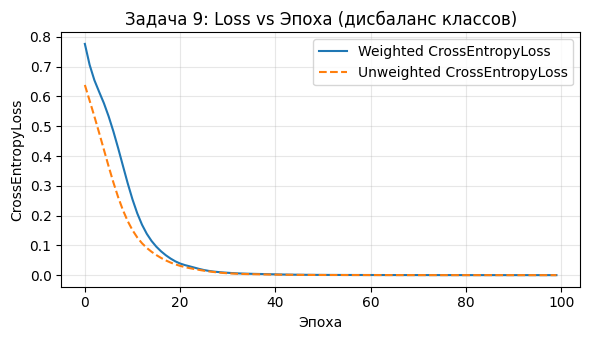

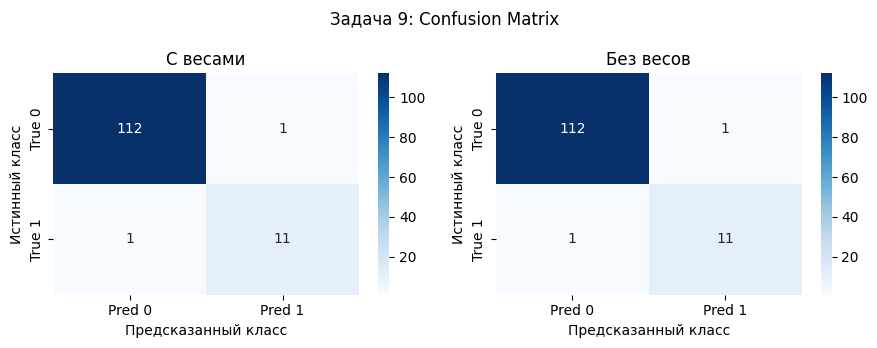


Вывод: веса классов усиливают штраф за ошибки на редком классе, поэтому модель меньше игнорирует класс 1.


In [10]:
# Генерация дисбалансированного датасета
torch.manual_seed(SEED)
np.random.seed(SEED)

n_total = 500
n_features_cls = 10
n_class0 = 450   # 90% - мажоритарный класс
n_class1 = 50    # 10% - миноритарный класс

# Генерируем данные с разными центрами для двух классов
X_cls0 = np.random.randn(n_class0, n_features_cls).astype(np.float32)
X_cls1 = np.random.randn(n_class1, n_features_cls).astype(np.float32) + 1.5  # Сдвиг центра

X_cls = np.vstack([X_cls0, X_cls1])                                    # (500, 10)
y_cls = np.concatenate([np.zeros(n_class0), np.ones(n_class1)]).astype(np.int64)  # (500,)
# dtype=int64 (long) - обязательно для CrossEntropyLoss!

# Перемешиваем
shuffle_idx = np.random.permutation(n_total)
X_cls = X_cls[shuffle_idx]
y_cls = y_cls[shuffle_idx]

# Train/Test split (стратифицированный - сохраняет пропорции классов)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.25, random_state=SEED, stratify=y_cls
)

# Нормализация
scaler_c = StandardScaler()
X_train_c = scaler_c.fit_transform(X_train_c)
X_test_c = scaler_c.transform(X_test_c)

# Конвертация в тензоры
X_train_ct = torch.tensor(X_train_c, dtype=torch.float32)   # (375, 10)
X_test_ct = torch.tensor(X_test_c, dtype=torch.float32)      # (125, 10)
y_train_ct = torch.tensor(y_train_c, dtype=torch.long)       # (375,) - long для CrossEntropyLoss!
y_test_ct = torch.tensor(y_test_c, dtype=torch.long)         # (125,) - long!

# Вычисление весов классов
unique_classes, counts = np.unique(y_train_c, return_counts=True)
# Inverse frequency: w_i = N / (C * n_i)
# N = len(y_train_c), C = len(unique_classes)
class_weights = len(y_train_c) / (len(unique_classes) * counts)
class_weights = torch.tensor(class_weights, dtype=torch.float32)
# class_weights ≈ [0.556, 5.0] — класс 1 получает вес ~9x больше

print(f"Распределение классов (train): {dict(zip(unique_classes.astype(int), counts))}")
print(f"Веса классов: {class_weights.tolist()}")

# Модель классификации
class ImbalancedNet(nn.Module):
    def __init__(self):
        super(ImbalancedNet, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(10, 32),   # 10 → 32
            nn.ReLU(),
            nn.Linear(32, 16),   # 32 → 16
            nn.ReLU(),
            nn.Linear(16, 2)     # 16 → 2 (логиты для 2 классов)
        )
        # Выход: 2 логита (по одному на класс).
        # CrossEntropyLoss сама применит softmax + NLLLoss.

    def forward(self, x):
        return self.net(x)       # (N, 2) — логиты

# Обучение: с весами и без
def train_classifier(use_weights, epochs=100, lr=0.01):
    """Обучает классификатор с/без весов классов."""
    torch.manual_seed(SEED)
    model = ImbalancedNet()

    if use_weights:
        # CrossEntropyLoss с весами: weight=class_weights
        # Веса применяются к каждому примеру в зависимости от его класса
        criterion = nn.CrossEntropyLoss(weight=class_weights)
    else:
        # Без весов - все классы равнозначны
        criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    for epoch in range(epochs):
        model.train()
        logits = model(X_train_ct)                    # (375, 2) - логиты
        loss = criterion(logits, y_train_ct)          # CrossEntropyLoss(логиты, метки_long)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    return model, train_losses

# Модель с весами классов
model_weighted, losses_weighted = train_classifier(use_weights=True)

# Модель без весов
model_unweighted, losses_unweighted = train_classifier(use_weights=False)

# Оценка
def evaluate_classifier(model, X_test, y_test, model_name):
    """Оценивает классификатор: accuracy, confusion matrix, recall."""
    model.eval()
    with torch.no_grad():
        logits = model(X_test)                        # (125, 2) - логиты
        # argmax по оси классов → предсказанный класс
        preds = torch.argmax(logits, dim=1)           # (125,) - предсказания
        # dim=1: argmax по столбцам (классам), а не по строкам (примерам)

    acc = accuracy_score(y_test.numpy(), preds.numpy())
    cm = confusion_matrix(y_test.numpy(), preds.numpy())

    print(f"\n{'='*40}")
    print(f"Модель: {model_name}")
    print(f"{'='*40}")
    print(f"Test accuracy: {acc:.3f}")
    print(f"Confusion matrix:\n {cm}")
    print(classification_report(y_test.numpy(), preds.numpy(),
                                target_names=['Class 0', 'Class 1'],
                                zero_division=0))
    return acc, cm

acc_w, cm_w = evaluate_classifier(model_weighted, X_test_ct, y_test_ct, "С весами (weighted)")
acc_uw, cm_uw = evaluate_classifier(model_unweighted, X_test_ct, y_test_ct, "Без весов (unweighted)")

# Визуализация: кривые обучения
plt.figure(figsize=(6, 3.5))
plt.plot(losses_weighted, label='Weighted CrossEntropyLoss', linewidth=1.5)
plt.plot(losses_unweighted, label='Unweighted CrossEntropyLoss', linewidth=1.5, linestyle='--')
plt.title("Задача 9: Loss vs Эпоха (дисбаланс классов)")
plt.xlabel("Эпоха")
plt.ylabel("CrossEntropyLoss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Визуализация: Confusion Matrix (heatmap)
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

for ax, cm, title in zip(axes, [cm_w, cm_uw],
                           ['С весами', 'Без весов']):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred 0', 'Pred 1'],
                yticklabels=['True 0', 'True 1'])
    ax.set_title(title)
    ax.set_ylabel('Истинный класс')
    ax.set_xlabel('Предсказанный класс')

plt.suptitle("Задача 9: Confusion Matrix", fontsize=12)
plt.tight_layout()
plt.show()

# Вывод
print("\nВывод: веса классов усиливают штраф за ошибки на редком классе, "
      "поэтому модель меньше игнорирует класс 1.")

---

# ИТОГОВАЯ ТАБЛИЦА: КОГДА ИСПОЛЬЗОВАТЬ КАКУЮ LOSS-ФУНКЦИЮ

| Задача | Loss Function | Когда использовать | Примеры |
|--------|---------------|--------------------|----------|
| Многоклассовая классификация (C≥2) | **CrossEntropyLoss** | Взаимно исключающие классы | Классификация изображений (MNIST), распознавание животных |
| Бинарная классификация | **BCEWithLogitsLoss** | Двуклассовая задача, один выход | Обнаружение спама, предсказание CTR |
| Регрессия с выбросами | **HuberLoss** | Данные содержат аномалии | Финансовые прогнозы, анализ датчиков |
| Многокритериальная задача | **Комбинированная** (α·L1 + (1-α)·L2) | Нужен компромисс между метриками | Multi-task learning, балансировка требований |
| Дисбалансированная классификация | **Weighted CrossEntropyLoss** | Классы недопредставлены неравномерно | Обнаружение редких болезней, fraud detection |

---

# ПОЛЕЗНЫЕ СОВЕТЫ

1. **Всегда нормализуйте признаки** (StandardScaler, MinMaxScaler).
2. **Проверяйте распределение классов** перед выбором loss.
3. **Используйте validation set** для контроля overfitting.
4. **Экспериментируйте с hyperparameters** (lr, weights, alpha).
5. **Визуализируйте learning curves** для диагностики.
6. **Не забывайте про evaluation metrics** (accuracy, precision, recall, F1, AUC).

---